In [ ]:
!pip install "numpy<2.0"

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

例えば、変圧器のオイル温度は以下の要因で変動する：

負荷（電流・電力）

周囲温度

時間帯（昼夜）

運転状態

物理を知らないと
「なんでこの特徴量が効いてるの？」
が説明しづらい。

2. 特徴量設計の質
例えば、負荷と温度の関係は非線形なので、

対数変換

移動平均

温度差分
などの特徴量が有効になる可能性が高い。

物理を知っていると「なぜその特徴量を作ったか」を説明しやすい。

### もし「物理の知識がないけど不安」という場合は、
### 最低限以下だけ押さえれば十分：

変圧器のオイル温度は負荷と周囲温度で決まる

温度は慣性があるので急には変わらない

異常時は温度が急上昇することがある

## データセットの期間は 2016 年 7 月～2018 年 7 月です。

## データ詳細
選択されたページの説明に基づいて、**ETT-small**データセットに含まれる `h1`, `h2`, `m1`, `m2` の各ファイルの内容および違いについて解説します。

**データセットの構成**
中国の省の2つの異なる地域（ステーション）から収集された2台の変圧器のデータです。

* **1**（h1 / m1）：地域1の変圧器データ
* **2**（h2 / m2）：地域2の変圧器データ

**記録間隔（サンプリング周期）の違い**

* **`m1` / `m2`（分単位データ：15分刻み）**
* 各データポイントが記録された2年分のデータです。
* 15分ごとに1回記録されており、データセットごとの総データ数は **70,080 個**（2年 × 365日 × 24時間 × 4回）です。


* **`h1` / `h2`（時間単位データ：1時間刻み）**
* 開発や実験を迅速化するために作成された、1時間単位のバリアントデータです。



**含まれるデータ項目（全8特徴量）**
すべてのファイル（h1, h2, m1, m2）において、以下の共通の8つの列（ヘッダー）で構成されています。

* **date**：記録された日時
* **HUFL**（High Use Full Load）：高使用・フル負荷
* **HULL**（High Use Low Load）：高効率・低負荷
* **MUFL**（Middle Use Full Load）：中使用・フル負荷
* **MULL**（Middle Use Low Load）：中使用・低負荷
* **LUFL**（Low Use Full Load）：低使用・フル負荷
* **LULL**（Low Use Low Load）：低使用・低負荷
* **OT**（Oil Temperature）：油温（予測目標値）

## 目的　オイル温度を将来予測することで、実際の運用・保全判断にどの程度価値を出せそうか？
## 目標：オイル温度の閾値を超える数時間前に予兆を予測すること

## 可視化
### 負荷変動や外部要因の影響がオイル温度にどのような影響を与えるのか。時系列で見る
#### ・OTとそれ以外の変数を時系列でグラフにして、季節ごとのトレンドはないかをみる。
### なんで二つの工場を出しているのか、比べると何か見えるかも、ビジネス的なアプローチができるかもしれない。

#　変電所や大規模施設等にある高圧〜特別高圧用の変圧器（巨大な冷却油タンクや冷却器を備えた設備）と仮定

# 工場１

In [28]:
csv_in ='./data/ETTh1.csv'
df = pd.read_csv(csv_in,sep=',',header=0)

print(df.shape)
print(df.info())
display(df.head())
display(df.tail())

Task was destroyed but it is pending!
task: <Task pending name='Task-9102' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at C:\Users\s1f10\miniconda3\envs\ds2026\lib\site-packages\ipykernel\utils.py:76> wait_for=<Task pending name='Task-9103' coro=<_async_in_context.<locals>.preserve_context() running at C:\Users\s1f10\miniconda3\envs\ds2026\lib\site-packages\ipykernel\utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\s1f10\miniconda3\envs\ds2026\lib\site-packages\zmq\eventloop\zmqstream.py:563]>


(17420, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    17420 non-null  object 
 1   HUFL    17420 non-null  float64
 2   HULL    17420 non-null  float64
 3   MUFL    17420 non-null  float64
 4   MULL    17420 non-null  float64
 5   LUFL    17420 non-null  float64
 6   LULL    17420 non-null  float64
 7   OT      17420 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.1+ MB
None


C:\Users\s1f10\miniconda3\envs\ds2026\lib\site-packages\pandas\io\formats\format.py:1311: RuntimeWarning: coroutine '_async_in_context.<locals>.preserve_context' was never awaited
  float_format(value=v)  # type: ignore[operator,call-arg]
Task was destroyed but it is pending!
task: <Task pending name='Task-9103' coro=<_async_in_context.<locals>.preserve_context() running at C:\Users\s1f10\miniconda3\envs\ds2026\lib\site-packages\ipykernel\utils.py:68> cb=[Task.task_wakeup()]>
Task was destroyed but it is pending!
task: <Task pending name='Task-9138' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at C:\Users\s1f10\miniconda3\envs\ds2026\lib\site-packages\ipykernel\utils.py:76> wait_for=<Task pending name='Task-9139' coro=<_async_in_context.<locals>.preserve_context() running at C:\Users\s1f10\miniconda3\envs\ds2026\lib\site-packages\ipykernel\utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\s1f10\miniconda3\envs\

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
17415,2018-06-26 15:00:00,-1.674,3.550,-5.615,2.132,3.472,1.523,10.904
17416,2018-06-26 16:00:00,-5.492,4.287,-9.132,2.274,3.533,1.675,11.044
17417,2018-06-26 17:00:00,2.813,3.818,-0.817,2.097,3.716,1.523,10.271
17418,2018-06-26 18:00:00,9.243,3.818,5.472,2.097,3.655,1.432,9.778
17419,2018-06-26 19:00:00,10.114,3.550,6.183,1.564,3.716,1.462,9.567


In [29]:

df['date']= pd.to_datetime(df['date'])

In [30]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    17420 non-null  datetime64[ns]
 1   HUFL    17420 non-null  float64       
 2   HULL    17420 non-null  float64       
 3   MUFL    17420 non-null  float64       
 4   MULL    17420 non-null  float64       
 5   LUFL    17420 non-null  float64       
 6   LULL    17420 non-null  float64       
 7   OT      17420 non-null  float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 1.1 MB
None


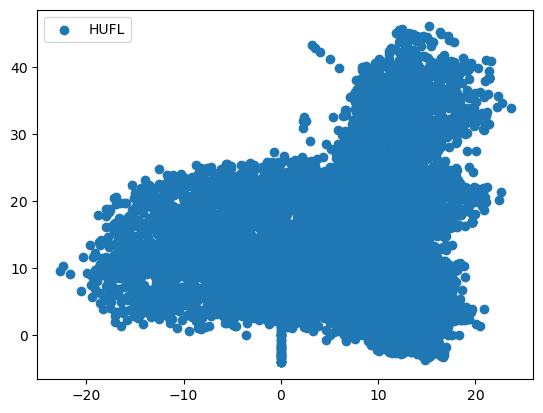

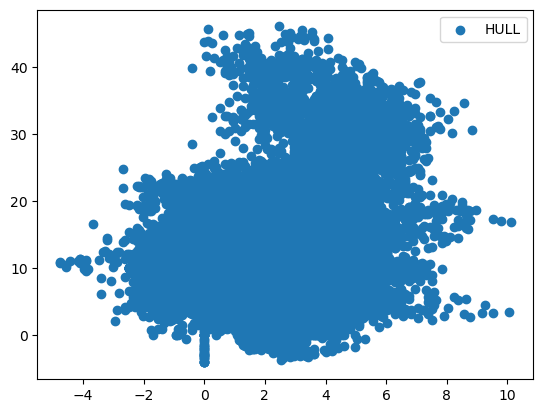

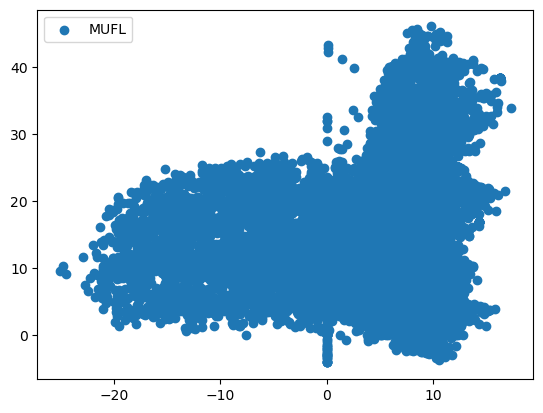

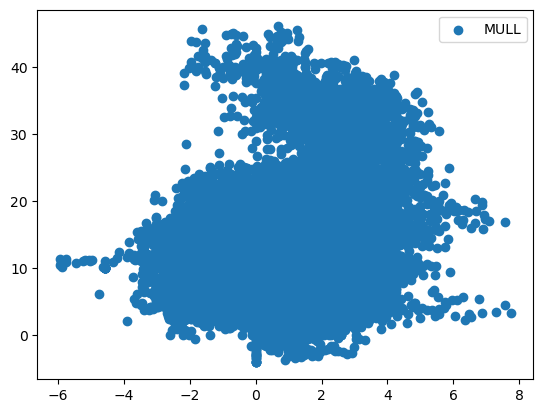

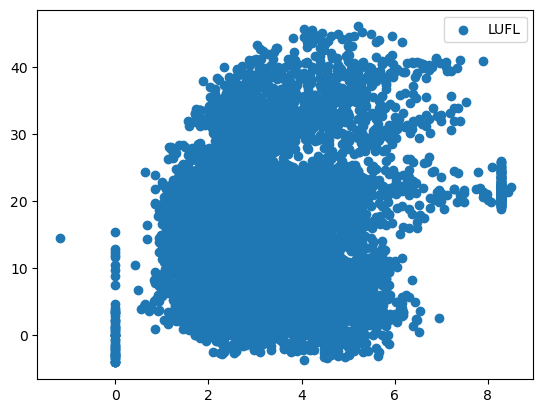

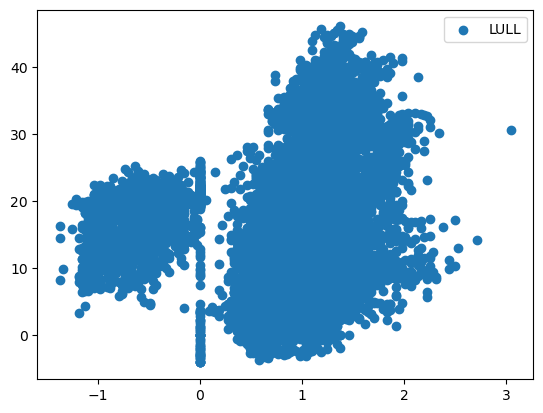

In [31]:
for c in ['HUFL','HULL','MUFL','MULL','LUFL','LULL']:
    plt.scatter(df[c],df['OT'],label=c)
    plt.legend()
    plt.show()

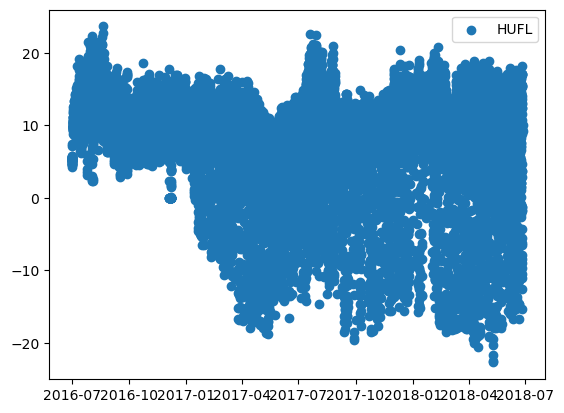

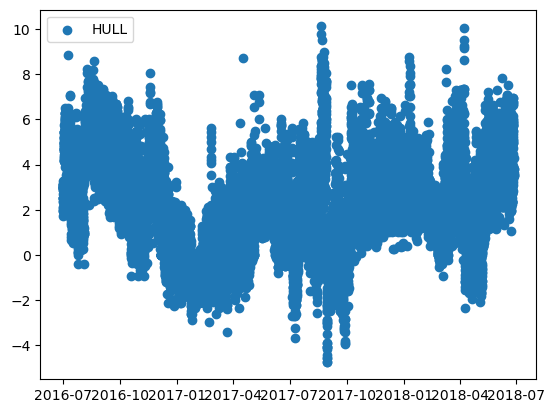

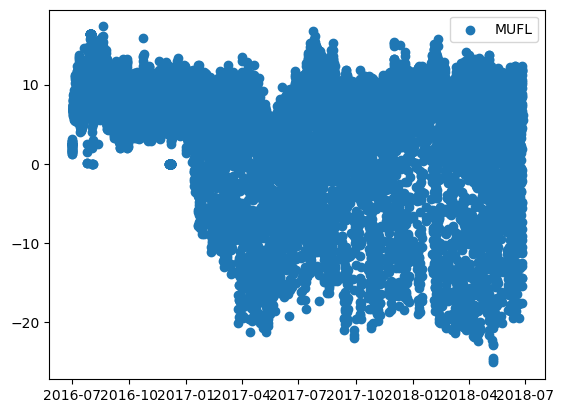

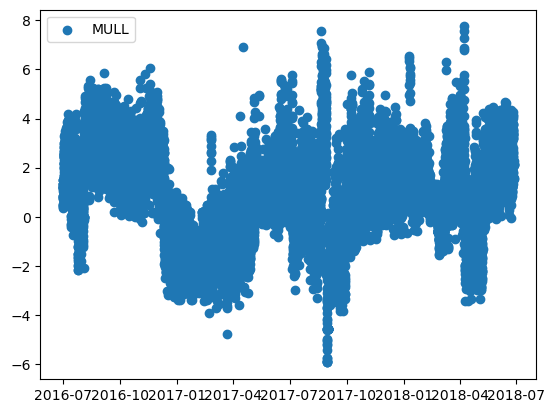

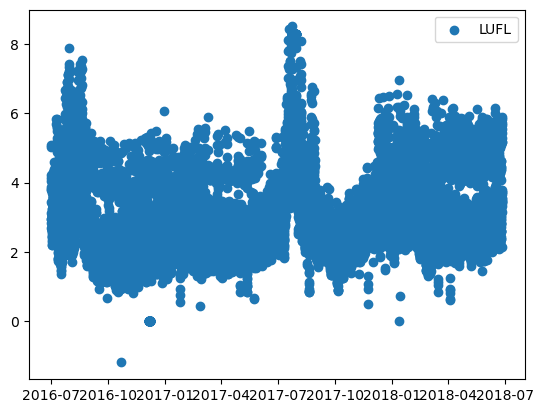

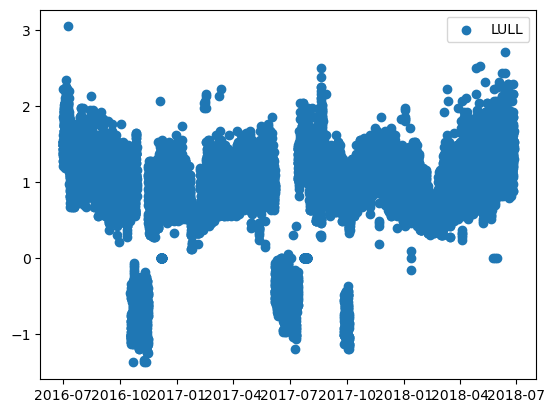

In [32]:
for c in ['HUFL','HULL','MUFL','MULL','LUFL','LULL']:
    plt.scatter(df['date'],df[c],label=c)
    plt.legend()
    plt.show()

In [33]:
# datetime型なら、年（year）を数値で指定するのがベスト
df_2017 = df[df['date'].dt.year == 2017]
display(df_2017.head())
display(df_2017.tail())
print(df.info())

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
4416,2017-01-01 00:00:00,12.927,1.273,8.919,-0.959,4.904,1.432,10.200
4417,2017-01-01 01:00:00,13.798,1.674,9.985,0.036,4.264,1.218,10.060
4418,2017-01-01 02:00:00,13.597,1.407,9.097,-0.142,4.142,1.097,9.919
4419,2017-01-01 03:00:00,13.195,1.942,9.310,-0.497,4.234,1.249,9.215
4420,2017-01-01 04:00:00,14.468,2.076,10.163,-0.142,4.508,1.401,10.130


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
13171,2017-12-31 19:00:00,14.535,3.952,9.808,2.523,4.599,0.883,4.221
13172,2017-12-31 20:00:00,14.535,3.952,9.808,2.523,4.599,0.883,4.221
13173,2017-12-31 21:00:00,14.535,3.952,9.808,2.523,4.599,0.883,4.221
13174,2017-12-31 22:00:00,14.535,3.952,9.808,2.523,4.599,0.883,4.221
13175,2017-12-31 23:00:00,14.535,3.952,9.808,2.523,4.599,0.883,4.221


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    17420 non-null  datetime64[ns]
 1   HUFL    17420 non-null  float64       
 2   HULL    17420 non-null  float64       
 3   MUFL    17420 non-null  float64       
 4   MULL    17420 non-null  float64       
 5   LUFL    17420 non-null  float64       
 6   LULL    17420 non-null  float64       
 7   OT      17420 non-null  float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 1.1 MB
None


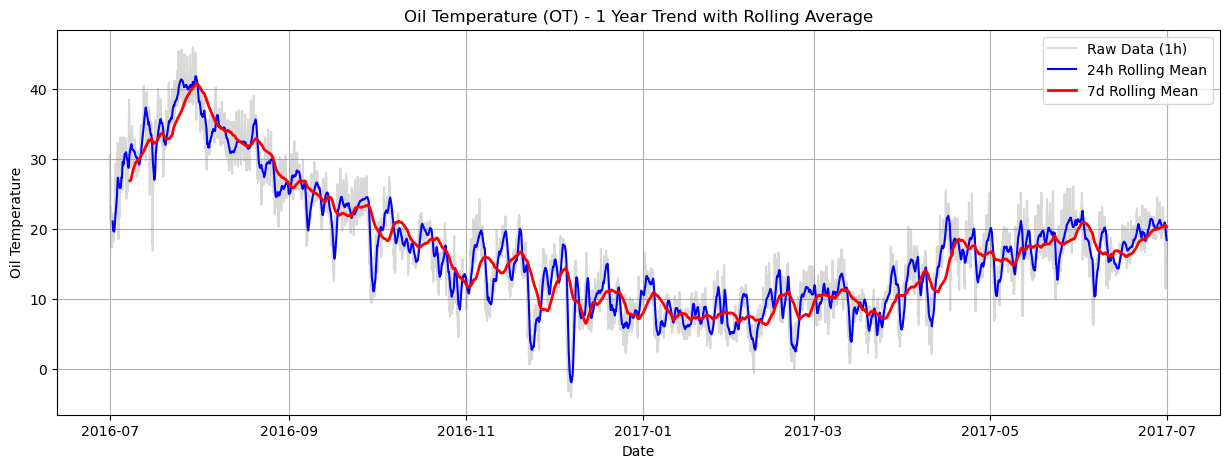

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# データの読み込み（例: ETTh1）
df["date"] = pd.to_datetime(df["date"])

# 1年分にフィルタリング
df_1year = df[(df["date"] >= "2016-07-01") & (df["date"] < "2017-07-01")].copy()

# 24時間移動平均と7日（168時間）移動平均の計算
df_1year["OT_24h_mean"] = df_1year["OT"].rolling(window=24).mean()
df_1year["OT_7d_mean"] = df_1year["OT"].rolling(window=168).mean()

# プロット
plt.figure(figsize=(15, 5))
plt.plot(
    df_1year["date"],
    df_1year["OT"],
    alpha=0.3,
    color="gray",
    label="Raw Data (1h)",
)
plt.plot(
    df_1year["date"],
    df_1year["OT_24h_mean"],
    color="blue",
    linewidth=1.5,
    label="24h Rolling Mean",
)
plt.plot(
    df_1year["date"],
    df_1year["OT_7d_mean"],
    color="red",
    linewidth=2,
    label="7d Rolling Mean",
)

plt.title("Oil Temperature (OT) - 1 Year Trend with Rolling Average")
plt.xlabel("Date")
plt.ylabel("Oil Temperature")
plt.legend()
plt.grid(True)
plt.show()

### 中国には四季があるため、それをもとに分析する

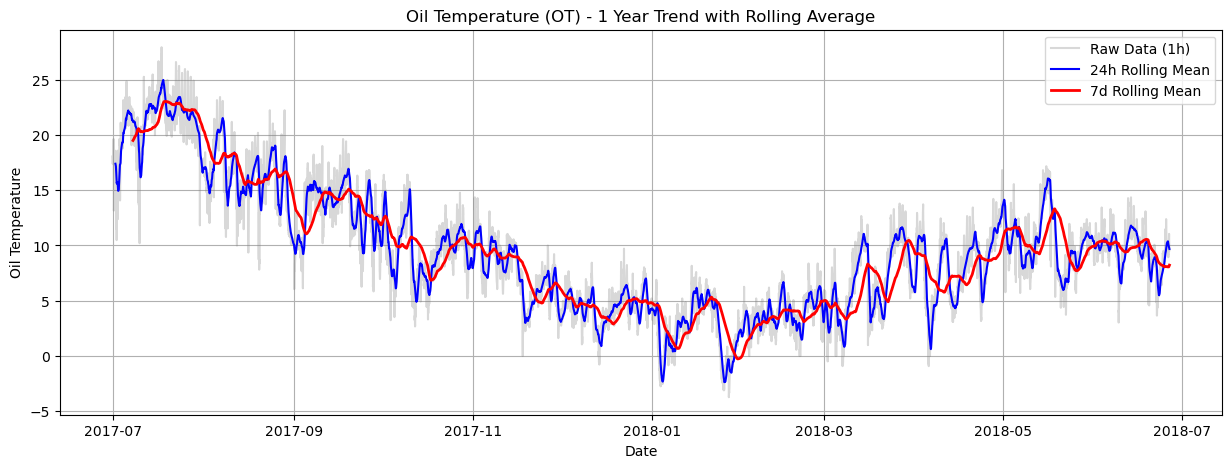

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

# データの読み込み（例: ETTh1）
df["date"] = pd.to_datetime(df["date"])

# 1年分にフィルタリング
df_1year = df[(df["date"] >= "2017-07-01") & (df["date"] < "2018-07-01")].copy()

# 24時間移動平均と7日（168時間）移動平均の計算
df_1year["OT_24h_mean"] = df_1year["OT"].rolling(window=24).mean()
df_1year["OT_7d_mean"] = df_1year["OT"].rolling(window=168).mean()

# プロット
plt.figure(figsize=(15, 5))
plt.plot(
    df_1year["date"],
    df_1year["OT"],
    alpha=0.3,
    color="gray",
    label="Raw Data (1h)",
)
plt.plot(
    df_1year["date"],
    df_1year["OT_24h_mean"],
    color="blue",
    linewidth=1.5,
    label="24h Rolling Mean",
)
plt.plot(
    df_1year["date"],
    df_1year["OT_7d_mean"],
    color="red",
    linewidth=2,
    label="7d Rolling Mean",
)

plt.title("Oil Temperature (OT) - 1 Year Trend with Rolling Average")
plt.xlabel("Date")
plt.ylabel("Oil Temperature")
plt.legend()
plt.grid(True)
plt.show()

###  夏は外気温が高くなるため、オイルも自然と熱くなる。8月ごろに40℃のオイル温度になっている
#####  オイル温度を決める要因：負荷（電流・電力）、周囲温度、時間帯（昼夜）、運転状態

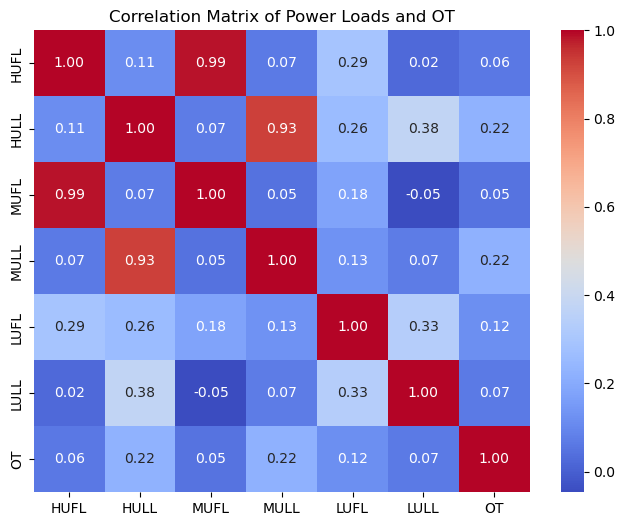

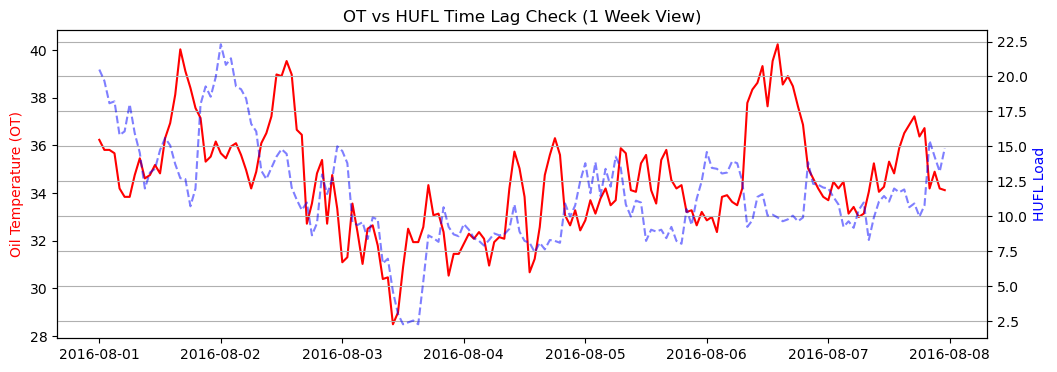

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. 相関ヒートマップの作成
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Correlation Matrix of Power Loads and OT")
plt.show()

# 2. OTと代表的負荷（HUFL）のラグ関係の可視化（1週間分）
df_sample = df[(df["date"] >= "2016-08-01") & (df["date"] < "2016-08-08")]

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(df_sample["date"], df_sample["OT"], color="red", label="OT (Target)")
ax1.set_ylabel("Oil Temperature (OT)", color="red")

ax2 = ax1.twinx()
ax2.plot(
    df_sample["date"],
    df_sample["HUFL"],
    color="blue",
    alpha=0.5,
    linestyle="--",
    label="HUFL",
)
ax2.set_ylabel("HUFL Load", color="blue")

plt.title("OT vs HUFL Time Lag Check (1 Week View)")
plt.grid(True)
plt.show()